In [109]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [84]:
def f(x):
    return 3*x**2 - 4*x + 5

In [85]:
f(3.0)

20.0

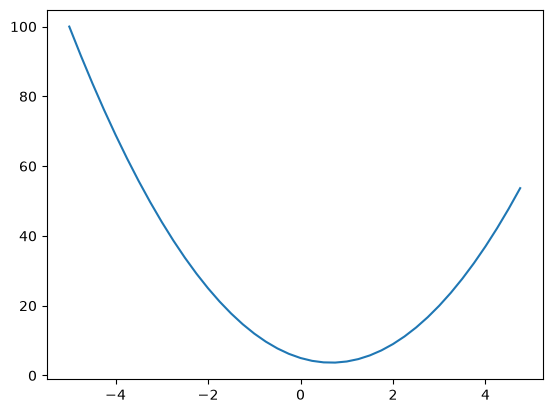

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [13]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

d1 = a*b + c
c += h
d2 = a*b + c
print('d1',d1)
print('d2',d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [98]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = ''
        
    def __add__(self,other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self + other
    
    def __mul__(self,other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance (other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward
        
        return out
    
            
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out


    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad 
        
        out._backward = _backward
        return out
   
    def backward(self):
        topo = []
        visited =set ()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed (topo):
            node._backward()
 
    def __repr__(self):
        return f"Value(data = {self.data})"


In [104]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432,label='b')
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label ='n'
#----
e = (2*n).exp()
o = (e - 1)/(e + 1)

o.backward()
print (n.grad)

0.5


In [74]:
import torch

In [105]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 +b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [204]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range (nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
        
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range (nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
        
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [205]:
x = [2.0, 3.0, -1.0]
model = MLP(3, [4, 4, 1])
model(x)

Value(data = -0.7314824571966252)

In [206]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [236]:
for i in range(30):

        #foward pass
        ypred = [model(x) for x in xs]
        loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
        
        #backward pass
        for p in model.parameters():
            p.grad = 0.0
        loss.backward()
        
        #update
        for p in model.parameters():
            p.data += -0.1 * p.grad

        print(i, loss.data)

0 0.004972996647909379
1 0.004885471070025904
2 0.004800885704449488
3 0.00471909629302697
4 0.004639967816140414
5 0.004563373766996026
6 0.004489195493128589
7 0.004417321597978325
8 0.004347647396251977
9 0.004280074417518622
10 0.004214509953136653
11 0.004150866642168133
12 0.00408906209242736
13 0.004029018533239297
14 0.003970662496858802
15 0.003913924525832539
16 0.0038587389038748088
17 0.003805043408086036
18 0.003752779080566876
19 0.003701890017682943
20 0.003652323175410423
21 0.0036040281893513987
22 0.0035569572081468243
23 0.003511064739139421
24 0.0034663075052499934
25 0.0034226443121291947
26 0.003380035924735754
27 0.003338444952570677
28 0.0032978357428687195
29 0.0032581742811116456


In [237]:
ypred

[Value(data = 0.9843213640192156),
 Value(data = -0.9657023418047181),
 Value(data = -0.9712288173941843),
 Value(data = 0.9682471363704607)]

In [201]:
ypred = [model(x) for x in xs]
ypred

[Value(data = 0.09049864551286567),
 Value(data = -0.7928989242259741),
 Value(data = -0.7957864299382249),
 Value(data = 0.9991254753912229)]